In [1]:
import yaml
import torch
import pytorch_lightning as pl
from tqdm.auto import tqdm
import torch.nn as nn
import numpy as np 

In [25]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule
from corpus.jsinV3AttnTrackingValidation import jsinV3_attn_tracking_validation
from corpus.jsinV3_attn_multi_talker_w_audioset import jsinV3_attn_multi_talker_w_audioset
import src.audio_transforms as at


In [26]:
path = 'config/attentional_cue/attn_cue_speech_and_noise_coch_attn_only.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [27]:

audio_config = config['data']['audio']
IIR_COCH = not audio_config['rep_kwargs']['rep_on_gpu']

audio_transforms = at.AudioCompose([
            at.AudioToTensor(),
            at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), # set to same as training 
            at.RMSNormalizeForegroundAndBackground(rms_level=0.1),
            at.UnsqueezeAudio(dim=0),
            # at.AudioToAudioRepresentation(**audio_config),
])

bg_combine_transforms = at.AudioCompose([
        at.AudioToTensor(),
        at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), # set to same as training 
        at.RMSNormalizeForegroundAndBackground(rms_level=0.1),
        at.UnsqueezeAudio(dim=0),
    ])


cochgram_transforms = at.AudioCompose([
            at.UnsqueezeAudio(dim=0),
            at.AudioToAudioRepresentation(**audio_config),

])

center_crop=False
binaural=False
using FIR cochleagram


In [28]:

config['layernorm_first'] = True
config['data']['corpus']['n_talkers'] = 1 

ckpt_path = 'attn_cue_models/attn_cue_match_target_speech_and_noise_coch_attn_only/checkpoints/epoch=1-step=20349.ckpt'

model = AttentionalTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config)
del config['data']['corpus']['with_audioset'] 
dataset = jsinV3_attn_multi_talker_w_audioset(**config['data']['corpus'],
                                          mode='val',
                                          with_audioset = False,
                                          transform=[audio_transforms,bg_combine_transforms],
                                          demo=True)

dataloader = torch.utils.data.DataLoader(
            dataset,
            batch_size=1,
            num_workers=0
        )


ln_first
Using attention at cochleagram only
center_crop=False
binaural=False
using FIR cochleagram


In [29]:

# Set hook to get activations 
class SigmoidLayer(nn.Module):
    def __init__(self, bias, threshold, slope):
        super(SigmoidLayer, self).__init__()
        self.bias = bias
        self.threshold = threshold
        self.slope = slope
    
    def forward(self, x):
        return self.bias + (1 - self.bias) *  torch.sigmoid((x - self.threshold) * self.slope)
    
    
activations = {}


def get_activation(name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            cue, mixture = output
            output = mixture
        activations[name] = output.detach()
    return hook



In [30]:
get_name = lambda name: 'cochleagram' if name == '0' else 'model' 
{get_name(name):module for name, module in model.model.named_children()}


{'cochleagram': AttnAudioInputRepresentation(
   (full_rep): AudioToAudioRepresentation(
     (rep): AudioToCochlearRep(
       (downsampling_op): Resample()
       (Cochleagram): TimeDomainCochleagram(
         (compute_rep): ComputeSubbands()
         (downsampling): Resample()
       )
     )
     (compression): ClippedGradPower(
       (compression_function): ClippedGradPowerCompression()
     )
   )
 ),
 'model': AuditoryCNN(
   (norm_coch_rep): LayerNorm((1, 40, 16000), eps=1e-05, elementwise_affine=True)
   (attn_block_in): SimpleAttentionalGain(
     (time_average): AdaptiveAvgPool2d(output_size=(40, 1))
   )
   (conv0): Sequential(
     (0): LayerNorm((1, 40, 16000), eps=1e-05, elementwise_affine=True)
     (1): Conv2dSame(1, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
     (2): ReLU(inplace=True)
     (3): HannPooling2d()
   )
   (conv1): Sequential(
     (0): LayerNorm((32, 20, 4000), eps=1e-05, elementwise_affine=True)
     (1): Conv2dSame(32, 64, kernel_size=(2, 14

In [31]:
n_activations = 1

# Set hooks for sigmoid layers
sigmoid_layers = nn.Sequential()

attn_gain_outputs = {}
cue_act_dict = {}

# Get attention parameters 
get_name = lambda name: 'cochleagram' if name == '0' else 'model' 
modules = {get_name(name):module for name, module in model.model.named_children()}

model_modules = modules['model']
cochleagram = modules['cochleagram']

attn_modules = {name:module for name, module in model_modules.named_children() if 'attn' in name}
cnn_channels = dict(zip(attn_modules.keys(), [1, 32, 64, 256, 512, 512, 512, 512]))

for name, module in attn_modules.items():
    print(name)
    module.time_average.register_forward_hook(get_activation(f"{name}_attn_in"))
    module.register_forward_hook(get_activation(f"{name}_attn_out"))

    sigmoid_layers.add_module(name, SigmoidLayer(module.bias, module.threshold, module.slope))
    
    out_size = torch.mul(*module.time_average.output_size) * cnn_channels[name]
    
    cue_act_dict[name] = torch.empty((n_activations, out_size), device=model.device)
    attn_gain_outputs[name] = torch.empty((n_activations, out_size), device=model.device)


# set hooks for all conv & FC layers

conv_modules = {name:module for name, module in model_modules.named_children() if 'conv' in name or 'relufc' in name}

fg_reps = {}
bg_reps = {}
mixture_reps = {}

print("cochleagram")

cochleagram.register_forward_hook(get_activation('cochleagram'))
for name, module in conv_modules.items():
    print(name)
    if 'relufc' in name:
        module.register_forward_hook(get_activation(name)) # [2] is relu 
    else:
        module[2].register_forward_hook(get_activation(name)) # [2] is relu 

    fg_reps[name] = []
    bg_reps[name] = []
    mixture_reps[name] = []



attn_block_in
cochleagram
conv0
conv1
conv2
conv3
conv4
conv5
conv6
relufc


dict_keys(['conv0', 'conv1', 'conv2', 'conv3', 'conv4', 'conv5', 'conv6', 'relufc'])

In [36]:
model = model.eval()

sigmoid_layers = sigmoid_layers

ix = 0 

mixture_reps['cochleagram'] = []
fg_reps['cochleagram'] = []
bg_reps['cochleagram'] = []

loader = iter(dataloader)
with torch.no_grad():
    foreground, background, mixture, fg_cue, fg_target = next(loader)
    # foreground, background, mixture, fg_cue, fg_target = next(loader)
    # foreground, background, mixture, fg_cue, fg_target = next(loader)
    # foreground, background, mixture, fg_cue, fg_target = next(loader)


    # # convert to cochleagrams
    # if IIR_COCH:
    #     foreground, _ = cochgram_transforms(foreground, None)
    #     background, _ = cochgram_transforms(background, None)
    #     foreground = foreground.squeeze(0)
    #     background = background.squeeze(0)
    #     # save inputs
    #     mixture_reps['cochleagram'].append(mixture)
    #     fg_reps['cochleagram'].append(foreground)
    #     bg_reps['cochleagram'].append(background)

    # else:
    #     foreground = foreground.view(1,-1)
    #     background = background.view(1,-1)
    #     fg_cue = fg_cue.view(1,-1)
    #     mixture = mixture.view(1,-1)
    # send to device
    # foreground, background, mixture = foreground.cuda(), background.cuda(), mixture.cuda()
    # foreground, background, mixture = foreground, background, mixture
    # fg_cue = fg_cue
    # run mixture
    model.model.forward(fg_cue, mixture)
        
    # get cue gains 
    for layer in attn_gain_outputs.keys():
        attn_input = activations[f"{layer}_attn_in"]
        print(attn_input.shape)
        cue_act_dict[layer][ix,:] = attn_input.view(1,-1)#.detach()
        attn_gain_outputs[layer][ix,:] = sigmoid_layers.get_submodule(layer).forward(attn_input).view(1,-1)#.detach()

    # get mixture reps
    for layer in mixture_reps.keys():
        # if layer == 'cochleagram':
        #     continue 
        mixture_reps[layer].append(activations[layer])#.cpu().detach())
            
    # run fg
    model(fg_cue, foreground)
        
    for layer in fg_reps.keys():
        # if layer == 'cochleagram':
        #     continue 
        fg_reps[layer].append(activations[layer])#.cpu().detach())
            
    # run bg
    model(fg_cue, background)
        
    for layer in bg_reps.keys():
        # if layer == 'cochleagram':
        #     continue 
        bg_reps[layer].append(activations[layer])#.cpu().detach())

here
in  torch.Size([1, 1, 40000])
out  torch.Size([1, 1, 40, 16000])
in  torch.Size([1, 1, 40000])
out  torch.Size([1, 1, 40, 16000])
torch.Size([1, 1, 40, 1])
in  torch.Size([1, 1, 40000])
out  torch.Size([1, 1, 40, 16000])
in  torch.Size([1, 40000])
out  torch.Size([1, 1, 40, 16000])
in  torch.Size([1, 1, 40000])
out  torch.Size([1, 1, 40, 16000])
in  torch.Size([1, 40000])
out  torch.Size([1, 1, 40, 16000])


In [41]:
fg_reps['cochleagram'][0]

{'cue': tensor([[[[0.0928, 0.1205, 0.0920,  ..., 0.0486, 0.0426, 0.0414],
           [0.0851, 0.0847, 0.1444,  ..., 0.0621, 0.0650, 0.0668],
           [0.0595, 0.1057, 0.1192,  ..., 0.0855, 0.0848, 0.0798],
           ...,
           [0.0080, 0.0087, 0.0109,  ..., 0.0079, 0.0175, 0.0079],
           [0.0079, 0.0086, 0.0101,  ..., 0.3619, 0.3571, 0.3664],
           [0.0080, 0.0083, 0.0097,  ..., 0.0087, 0.0079, 0.0084]]]]),
 'mixture': tensor([[[[0.0713, 0.0948, 0.0079,  ..., 0.0336, 0.0079, 0.0397],
           [0.0645, 0.0760, 0.1130,  ..., 0.0661, 0.0418, 0.0671],
           [0.0561, 0.0914, 0.0948,  ..., 0.1195, 0.1188, 0.1220],
           ...,
           [0.0079, 0.0083, 0.0079,  ..., 0.3495, 0.3332, 0.3226],
           [0.0079, 0.0081, 0.0079,  ..., 0.5150, 0.5146, 0.5364],
           [0.0079, 0.0079, 0.0079,  ..., 0.0220, 0.0079, 0.0216]]]])}

In [101]:
attn_gain_outputs.keys()
attn_keys = list(attn_gain_outputs.keys())
layer_attn_map = {layer:attn_keys[i] for i, layer in enumerate(sorted(bg_reps.keys())) if 'fc' not in layer}

In [102]:
%matplotlib inline  
import matplotlib.pyplot as plt

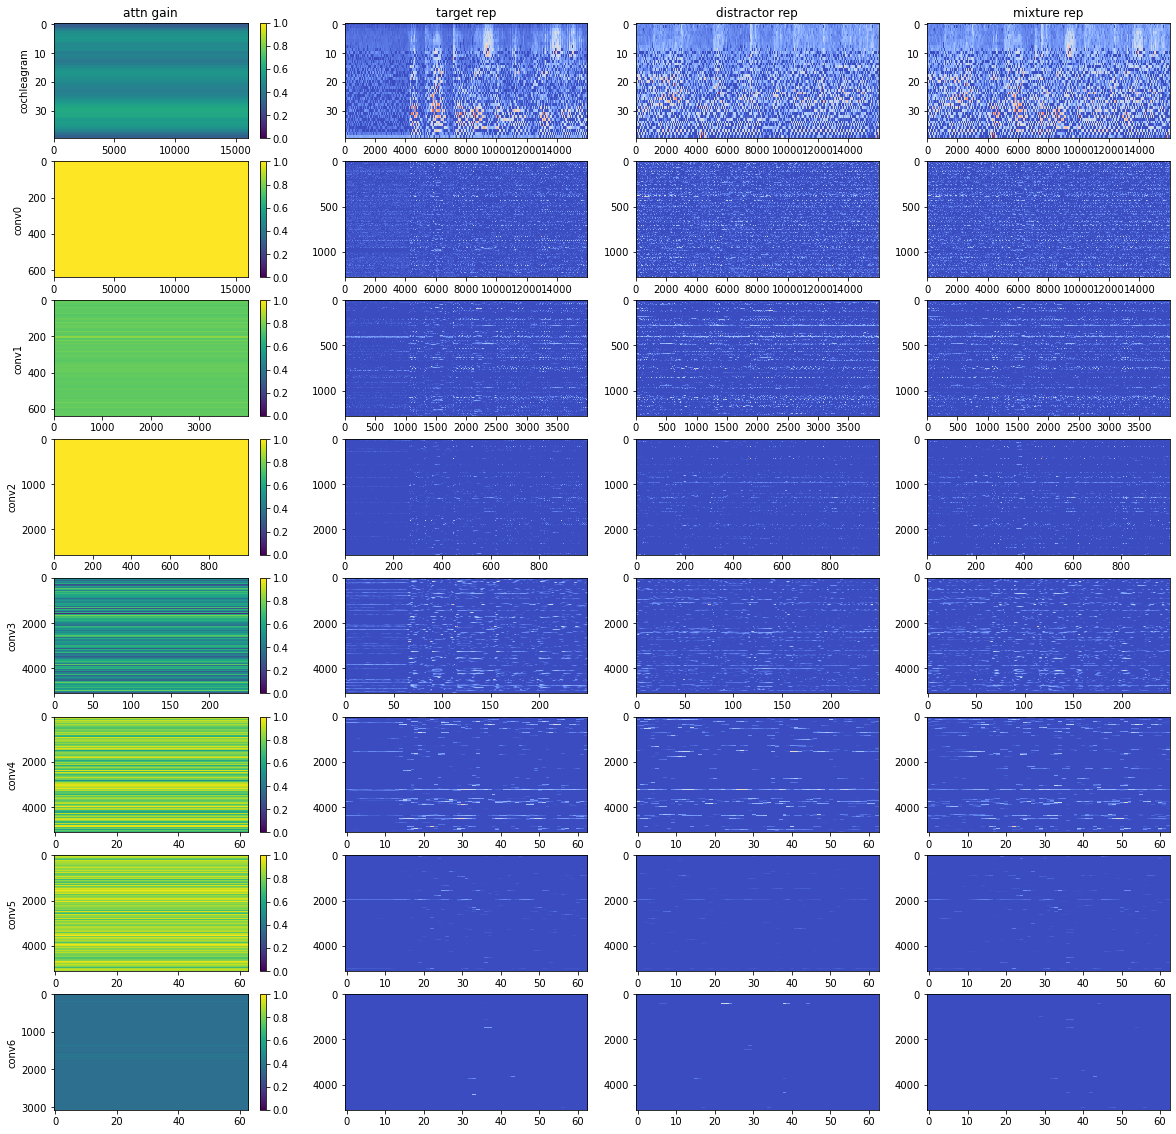

In [104]:
fig, axs = plt.subplots(len(layer_attn_map), 4, figsize=(20,20))

for i, layer in enumerate(sorted(layer_attn_map.keys())):
    attn_key = layer_attn_map[layer]
    channel, freq, time = fg_reps[layer][0].squeeze(0).shape
    # reshape gains to match rep shape
    attn_gains = attn_gain_outputs[attn_key].cpu().numpy().T.repeat(time,axis=1)
    # unpack acts 
    fg_act = fg_reps[layer][0].cpu().numpy().reshape(-1,time)
    bg_act = bg_reps[layer][0].cpu().numpy().reshape(-1,time)
    mixture_act = mixture_reps[layer][0].cpu().numpy().reshape(-1,time)

    # normalize
    fg_act = (fg_act - fg_act.min()) / (fg_act.max() - fg_act.min())
    bg_act = (bg_act - bg_act.min()) / (bg_act.max() - bg_act.min())
    mixture_act = (mixture_act - mixture_act.min()) / (mixture_act.max() - mixture_act.min())
    
    # plot
    gains = axs[i,0].imshow(attn_gains, aspect='auto',  vmin=0, vmax=1)
    # if i == 0:
    fig.colorbar(gains, ax=axs[i, 0])

    axs[i,1].imshow(fg_act, aspect='auto', vmin=fg_act.max()//2, vmax=fg_act.max(), cmap='coolwarm', interpolation='none')
    axs[i,2].imshow(bg_act, aspect='auto', vmin=bg_act.max()//2, vmax=bg_act.max(), cmap='coolwarm', interpolation='none')
    axs[i,3].imshow(mixture_act, aspect='auto', vmin=mixture_act.max()//2, vmax=mixture_act.max(), cmap='coolwarm', interpolation='none')
    if i == 0:
        axs[i,0].set_title(f"attn gain")
        axs[i,1].set_title(f"target rep")
        axs[i,2].set_title(f"distractor rep")
        axs[i,3].set_title(f"mixture rep")

    axs[i,0].set_ylabel(f"{layer}")


0.0